In [1]:
import pandas as pd
import numpy as np
import utils
import re
import glob
import os
import tidytcells as tt
from typing import Literal
from joblib import Parallel, delayed
import multiprocessing as mp
from collections import defaultdict
import itertools
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import Normalize
import seaborn as sns
from scipy import stats
import pickle
from itertools import combinations
from matplotlib.colors import LinearSegmentedColormap
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
# Set the rcParam for editable text in SVG
plt.rcParams['svg.fonttype'] = 'none'

/home/yipingzou2/.local/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Analysis

In [ ]:
def get_response_category(sample_id):
    """Extract response category from sample ID"""
    if 'CT' in sample_id:
        return "HC"
    elif 'NC' in sample_id:
        return "no_colitis"
    elif 'C' in sample_id:
        return "colitis"
    else:
        return sample_id

def perform_statistical_tests(df_plot, unique_samples, test_direction='two-sided', adjust_pvalues=True, adjust_method="FDR"):
    """
    Perform pairwise statistical comparisons between all samples with one-sided tests
    
    Parameters:
    test_direction: 'greater', 'less', or 'two-sided'
        - 'greater': Test if Sample1 > Sample2 (Sample1 has higher MI values)
        - 'less': Test if Sample1 < Sample2 (Sample1 has lower MI values)
        - 'two-sided': Test if Sample1 ≠ Sample2 (any difference)
    """
    from statsmodels.stats.multitest import multipletests
    
    all_results = []
    
    # Get MI values for each sample
    sample_data = {}
    for sample in unique_samples:
        sample_data[sample] = df_plot[df_plot['Sample_ID'] == sample]['MI_Value'].values
    
    # Perform pairwise comparisons
    total_comparisons = 0
    for sample1, sample2 in combinations(unique_samples, 2):
        total_comparisons += 1
        data1 = sample_data[sample1]
        data2 = sample_data[sample2]
        
        # Also calculate all three for comparison
        _, p_greater = stats.mannwhitneyu(data1, data2, alternative='greater')
        _, p_less = stats.mannwhitneyu(data1, data2, alternative='less')
        _, p_two_sided = stats.mannwhitneyu(data1, data2, alternative='two-sided')
        
        all_results.append({
            'Sample1': sample1,
            'Sample2': sample2,
            'Sample1_Response': get_response_category(sample1),
            'Sample2_Response': get_response_category(sample2),
            'Sample1_Mean': np.mean(data1),
            'Sample2_Mean': np.mean(data2),
            'Mean_Difference': np.mean(data1) - np.mean(data2),
            'P_Value_Raw': p_two_sided if test_direction == 'two-sided' else min(p_less, p_greater),
            'P_Value_less': p_less,
            'P_Value_greater': p_greater,
            'P_Value_Two_Sided': p_two_sided,
            'N1': len(data1),
            'N2': len(data2),
            'Test_Direction': test_direction
        })
    
    # Create DataFrame
    results_df = pd.DataFrame(all_results)
    
    if adjust_pvalues:
        # Apply multiple testing correction to the main p-value
        p_values = results_df['P_Value_Raw'].values 
        
        # Benjamini-Hochberg (FDR) - less conservative than Bonferroni
        rejected_fdr, p_adjusted_fdr, _, _ = multipletests(p_values, method='fdr_bh')
        
        # Bonferroni - more conservative
        rejected_bonf, p_adjusted_bonf, _, _ = multipletests(p_values, method='bonferroni')
        
        results_df['P_Value_FDR'] = p_adjusted_fdr
        results_df['P_Value_Bonferroni'] = p_adjusted_bonf
        results_df['Significant_Raw'] = results_df['P_Value_Raw'] < 0.05
        results_df['Significant_FDR'] = rejected_fdr
        results_df['Significant_Bonferroni'] = rejected_bonf
        
        # Filter significant results (you can choose which method to use)
        if adjust_method == "FDR":
            found_significant = results_df[results_df['Significant_FDR']].copy()
        else:
            found_significant = results_df[results_df['Significant_Bonferroni']].copy()
        
    else:
        results_df['Significant_Raw'] = results_df['P_Value_Raw'] < 0.05
        found_significant = results_df[results_df['Significant_Raw']].copy()
        
    return results_df, found_significant

def create_pvalue_heatmap(results_df, unique_samples, p_value_type='P_Value_Bonferroni', 
                         save_path=None, feature_pair=None):
    """
    Create upper triangle heatmap of p-values between samples
    """
    
    # Create p-value matrix
    n_samples = len(unique_samples)
    p_matrix = np.ones((n_samples, n_samples))
    
    # Fill the matrix with p-values
    sample_to_idx = {sample: i for i, sample in enumerate(unique_samples)}
    
    for _, row in results_df.iterrows():
        sample1_idx = sample_to_idx[row['Sample1']]
        sample2_idx = sample_to_idx[row['Sample2']]
        p_val = row[p_value_type]
        
        # Fill both positions (symmetric matrix)
        p_matrix[sample1_idx, sample2_idx] = p_val
        p_matrix[sample2_idx, sample1_idx] = p_val
    
    # Create mask for upper triangle (including diagonal)
    mask = np.tril(np.ones_like(p_matrix, dtype=bool))
    
    # Create response category annotations for samples
    sample_responses = [get_response_category(sample) for sample in unique_samples]
    
    # Create color mapping for response categories
    response_colors = {"HC": "#69A3DD", "no_colitis": "#BD2329", 
                      "colitis": "#4048A4"}
    
    # Create row colors for the heatmap
    row_colors = [response_colors.get(resp, 'gray') for resp in sample_responses]
    
    # Create the plot
    plt.figure(figsize=(6, 5))
    
    # Create heatmap with upper triangle mask
    sns.heatmap(p_matrix, 
                mask=mask,
                annot=True, 
                fmt='.2f',
                cmap='RdYlBu_r',
                center=0.05,
                vmin=0, 
                vmax=1,
                xticklabels=unique_samples,
                yticklabels=unique_samples,
                cbar_kws={'label': f'{p_value_type.replace("_", " ")}'})
    
    # Add response category color bar on the side
    ax = plt.gca()
    
    # Add colored rectangles for response categories
    for i, (sample, response) in enumerate(zip(unique_samples, sample_responses)):
        color = response_colors.get(response, 'gray')
        rect = plt.Rectangle((len(unique_samples) + 0.1, i), 0.3, 1, 
                           facecolor=color, edgecolor='black', linewidth=0.5)
        ax.add_patch(rect)
    
    # Adjust plot limits to accommodate the color bar
    ax.set_xlim(0, len(unique_samples) + 0.5)
    
    # Create legend for response categories
    legend_elements = []
    unique_responses = list(set(sample_responses))
    for response in ["HC", "no_colitis", "colitis"]:
        if response in unique_responses:
            legend_elements.append(
                plt.Rectangle((0,0),1,1, facecolor=response_colors[response], 
                            edgecolor='black', linewidth=0.5, label=response)
            )
    
    plt.legend(handles=legend_elements, title='Response Category', 
              bbox_to_anchor=(1.15, 1), loc='upper left')
    
    # Set title
    if feature_pair:
        plt.title(f'P-values Heatmap: {feature_pair[0]} vs {feature_pair[1]}\n({p_value_type.replace("_", " ")})')
    else:
        plt.title(f'P-values Heatmap ({p_value_type.replace("_", " ")})')
    
    plt.xlabel('Sample ID')
    plt.ylabel('Sample ID')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, transparent=True, bbox_inches='tight')
        print(f"Heatmap saved to: {save_path}")
    
    plt.show()

def create_mi_analysis_with_heatmap(mi_path, samples_path, analysis_type='samples', save_dir="figures/covid/samples", 
                                    p_value_type='P_Value_Bonferroni'):
    """
    Create MI analysis with p-value heatmaps for each feature pair.
    """
    
    # Load data
    mi = pd.read_pickle(mi_path)
    data_dict = pd.read_pickle(samples_path)
    
    # Create save directory if it doesn't exist
    os.makedirs(save_dir, exist_ok=True)
    
    # Process each feature pair
    for feature1, feature2 in list(mi.keys()):
        print(f"Processing {feature1} vs {feature2}...")
        
        mi_data = mi[(feature1, feature2)]
        n_resamples = len(mi_data)
        
        # Configuration for samples analysis
        if analysis_type == 'samples':
            sample_ids = list(data_dict.keys())
            response_order = ["HC", "no_colitis", "colitis"]
        
            # Prepare plot data
            plot_data = []
            for sample_idx, sample_id in enumerate(sample_ids):
                for resample_idx in range(n_resamples):
                    if resample_idx in mi_data:
                        mi_values_array = mi_data[resample_idx]
                        if sample_idx < len(mi_values_array):
                            plot_data.append({
                                'Sample_ID': sample_id,
                                'Response_Category': get_response_category(sample_id),
                                'MI_Value': mi_values_array[sample_idx],
                                'Resample_Index': resample_idx
                            })
        
        df_plot = pd.DataFrame(plot_data)
        if df_plot.empty:
            print(f"No data found for {feature1} vs {feature2}")
            continue
        
        # Calculate mean MI value for each sample
        sample_means = df_plot.groupby('Sample_ID')['MI_Value'].mean().to_dict()
        
        # Sort samples by response category first, then by mean MI value within category
        def sort_key_by_mean(sample_id):
            response = get_response_category(sample_id)
            response_priority = response_order.index(response) if response in response_order else 999
            mean_mi = sample_means.get(sample_id, 0)
            return (response_priority, -mean_mi)
        
        unique_samples = sorted(df_plot['Sample_ID'].unique(), key=sort_key_by_mean)
        df_plot_limited = df_plot[df_plot['Sample_ID'].isin(unique_samples)]
        
        # Statistical tests
        results_df, found_significant = perform_statistical_tests(
            df_plot_limited, unique_samples, 
            test_direction='two-sided',
            adjust_pvalues=True,
            adjust_method='Bonferroni'
        )
        
        # Create p-value heatmap
        save_path = os.path.join(save_dir, f'pvalue_heatmap_{feature1}_vs_{feature2}.png')
        create_pvalue_heatmap(results_df, unique_samples, 
                            p_value_type=p_value_type,
                            save_path=save_path,
                            feature_pair=(feature1, feature2))

def create_combined_mi_plot(mi_path, samples_path, analysis_type='samples', save_dir=None, 
                            p_value_type='P_Value_Bonferroni', select_features=None, 
                            show_individual=False, show_combined=True):
    """
    Create combined plot with scatter plot (left) and p-value heatmap (right) for each feature pair.
    """
    import numpy as np
    
    # Load data
    mi = pd.read_pickle(mi_path)
    data_dict = pd.read_pickle(samples_path)
    
    # Create save directory if it doesn't exist
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        os.makedirs(os.path.join(save_dir, 'individual_subfigures'), exist_ok=True)
    
    # Store data for all feature pairs for combined plot
    all_plot_data = []
    
    # Process each feature pair
    for feature1, feature2 in list(mi.keys()):
        print(f"Processing {feature1} vs {feature2}...")
        
        mi_data = mi[(feature1, feature2)]
        n_resamples = len(mi_data)
        
        # Configuration for samples analysis
        if analysis_type == 'samples':
            sample_ids = list(data_dict.keys())
            response_order = ["HC", "no_colitis", "colitis"]
        
            # Prepare plot data
            plot_data = []
            for sample_idx, sample_id in enumerate(sample_ids):
                for resample_idx in range(n_resamples):
                    if resample_idx in mi_data:
                        mi_values_array = mi_data[resample_idx]
                        if sample_idx < len(mi_values_array):
                            plot_data.append({
                                'Sample_ID': sample_id,
                                'Response_Category': get_response_category(sample_id),
                                'MI_Value': mi_values_array[sample_id],
                                'Resample_Index': resample_idx
                            })
        
        df_plot = pd.DataFrame(plot_data)
        if df_plot.empty:
            print(f"No data found for {feature1} vs {feature2}")
            continue
        
        # Calculate mean MI value for each sample
        sample_means = df_plot.groupby('Sample_ID')['MI_Value'].mean().to_dict()
        
        # Sort samples by response category first, then by mean MI value within category
        def sort_key_by_mean(sample_id):
            response = get_response_category(sample_id)
            response_priority = response_order.index(response) if response in response_order else 999
            mean_mi = sample_means.get(sample_id, 0)
            return (response_priority, -mean_mi)
        
        unique_samples = sorted(df_plot['Sample_ID'].unique(), key=sort_key_by_mean)
        df_plot_limited = df_plot[df_plot['Sample_ID'].isin(unique_samples)]
        
        # Statistical tests
        results_df, found_significant = perform_statistical_tests(
            df_plot_limited, unique_samples, 
            test_direction='two-sided',
            adjust_pvalues=True,
            adjust_method='Bonferroni'
        )
        
        # Store data for combined plot
        all_plot_data.append({
            'feature_pair': (feature1, feature2),
            'df_plot_limited': df_plot_limited,
            'unique_samples': unique_samples,
            'results_df': results_df
        })
        
        # ============ CREATE AND SAVE INDIVIDUAL SUBFIGURE ============
        fig_individual = plt.figure(figsize=(20, 8))
        gs_individual = fig_individual.add_gridspec(1, 3, width_ratios=[2, 2, 0.1], wspace=0.3)
        
        # LEFT PANEL: SCATTER PLOT (similar to the style in your image)
        ax1_individual = fig_individual.add_subplot(gs_individual[0, 0])
        response_colors = {"HC": "#69A3DD", "no_colitis": "#BD2329", 
                          "colitis": "#4048A4"}
        
        # Create age positions for each sample (Y-axis)
        sample_positions = {sample: i for i, sample in enumerate(unique_samples)}
        
        # Draw scatter plot for each sample
        for sample_id in unique_samples:
            sample_data = df_plot_limited[df_plot_limited['Sample_ID'] == sample_id]
            response_cat = get_response_category(sample_id)
            color = response_colors.get(response_cat, 'gray')
            
            # Get all MI values for this sample
            mi_values = sample_data['MI_Value'].values
            y_positions = [sample_positions[sample_id]] * len(mi_values)
            
            # Add some random jitter to avoid point overlap
            y_jitter = np.random.normal(0, 0.1, len(mi_values))
            y_positions_jittered = np.array(y_positions) + y_jitter
            
            # Draw scatter points
            ax1_individual.scatter(mi_values, y_positions_jittered, 
                                 color=color, alpha=1, s=100, edgecolors='white', linewidth=0.5)
            
            # Add mean line
            mean_mi = np.mean(mi_values)
            ax1_individual.plot([mean_mi, mean_mi], 
                              [sample_positions[sample_id] - 0.3, sample_positions[sample_id] + 0.3], 
                              color='black', linewidth=2, alpha=0.8)

        ax1_individual.set_yticks(range(len(unique_samples)))
        ax1_individual.set_yticklabels(unique_samples, rotation=0)
        ax1_individual.set_title(f'MI Distribution: {feature1}, {feature2}')
        ax1_individual.set_ylabel('Sample ID')
        ax1_individual.set_xlabel('Mutual Information Value')
        ax1_individual.grid(True, alpha=0.3)
        
        # RIGHT PANEL: HEATMAP
        ax2_individual = fig_individual.add_subplot(gs_individual[0, 1])
        n_samples = len(unique_samples)
        p_matrix = np.ones((n_samples, n_samples))
        sample_to_idx = {sample: i for i, sample in enumerate(unique_samples)}

        for _, row in results_df.iterrows():
            sample1_idx = sample_to_idx[row['Sample1']]
            sample2_idx = sample_to_idx[row['Sample2']]
            p_val = row[p_value_type]
            p_matrix[sample1_idx, sample2_idx] = p_val
            p_matrix[sample2_idx, sample1_idx] = p_val

        mask = np.zeros_like(p_matrix, dtype=bool)
        for i in range(n_samples):
            for j in range(n_samples):
                if j >= i:
                    mask[i, j] = True

        im_individual = sns.heatmap(p_matrix, 
                        mask=mask,
                        annot=True, 
                        fmt='.2f',
                        cmap='Blues_r',
                        vmin=0, 
                        vmax=1,
                        xticklabels=unique_samples,
                        yticklabels=unique_samples,
                        ax=ax2_individual,
                        cbar=False)

        ax2_individual.set_title(f'P-values ({p_value_type.replace("_", " ")})')
        ax2_individual.set_xlabel('Sample ID')
        ax2_individual.set_ylabel('Sample ID')
        ax2_individual.set_xticklabels(unique_samples, rotation=45, ha='right')
        ax2_individual.set_yticklabels(unique_samples, rotation=0)
        
        # COLORBAR
        ax3_individual = fig_individual.add_subplot(gs_individual[0, 2])
        cbar_individual = plt.colorbar(im_individual.collections[0], cax=ax3_individual)
        cbar_individual.set_label(f'{p_value_type.replace("_", " ")}', rotation=270, labelpad=20)
        
        # LEGEND
        legend_elements = []
        sample_responses = [get_response_category(sample) for sample in unique_samples]
        unique_responses = list(set(sample_responses))
        
        for response in ["HC", "no_colitis", "colitis"]:
            if response in unique_responses:
                legend_elements.append(
                    plt.Rectangle((0,0),1,1, facecolor=response_colors[response], 
                                edgecolor='black', linewidth=0.5, label=response)
                )
        
        fig_individual.legend(handles=legend_elements, title='Response Category', 
                  bbox_to_anchor=(0.95, 0.85), loc='upper left')
        
        plt.suptitle(f'MI Analysis: {feature1}, {feature2}', fontsize=16, y=0.95)
        
        # Save individual subfigure
        if save_dir:
            if select_features is None or (feature1, feature2) in select_features:
                individual_save_path = os.path.join(save_dir, 'individual_subfigures', 
                                                  f'subfigure_{feature1}_vs_{feature2}.pdf')
                fig_individual.savefig(individual_save_path, transparent=True, bbox_inches='tight')
                print(f"Individual subfigure saved to: {individual_save_path}")
        
        # Show individual plot if requested
        if show_individual:
            plt.show()
        else:
            plt.close(fig_individual)
    
    # ============ CREATE COMBINED FIGURE WITH ALL SUBFIGURES ============
    if not all_plot_data:
        print("No data to create combined figure")
        return
    
    n_pairs = len(all_plot_data)
    n_cols = min(2, n_pairs)
    n_rows = (n_pairs + n_cols - 1) // n_cols
    
    # Create combined figure
    fig_combined = plt.figure(figsize=(20*n_cols, 8*n_rows))
    
    for idx, data in enumerate(all_plot_data):
        feature1, feature2 = data['feature_pair']
        df_plot_limited = data['df_plot_limited']
        unique_samples = data['unique_samples']
        results_df = data['results_df']
        
        # Calculate subplot position
        row = idx // n_cols
        col = idx % n_cols
        
        # Create gridspec for this subplot
        gs_sub = fig_combined.add_gridspec(n_rows, n_cols*3, 
                                          width_ratios=[2, 2, 0.1]*n_cols, 
                                          wspace=0.1, hspace=0.3)
        
        # LEFT PANEL: SCATTER PLOT
        ax1 = fig_combined.add_subplot(gs_sub[row, col*3])
        
        response_colors = {"HC": "#69A3DD", "no_colitis": "#BD2329", 
                          "colitis": "#4048A4"}
        
        # Create positions for each sample
        sample_positions = {sample: i for i, sample in enumerate(unique_samples)}
        
        # Draw scatter plot for each sample
        for sample_id in unique_samples:
            sample_data = df_plot_limited[df_plot_limited['Sample_ID'] == sample_id]
            response_cat = get_response_category(sample_id)
            color = response_colors.get(response_cat, 'gray')
            
            # Get all MI values for this sample
            mi_values = sample_data['MI_Value'].values
            y_positions = [sample_positions[sample_id]] * len(mi_values)
            
            # Add some random jitter
            y_jitter = np.random.normal(0, 0.08, len(mi_values))
            y_positions_jittered = np.array(y_positions) + y_jitter
            
            # Draw scatter points
            ax1.scatter(mi_values, y_positions_jittered, 
                       color=color, alpha=1, s=100, edgecolors='white', linewidth=0.3)
            
            # Add mean line
            mean_mi = np.mean(mi_values)
            ax1.plot([mean_mi, mean_mi], 
                    [sample_positions[sample_id] - 0.25, sample_positions[sample_id] + 0.25], 
                    color='black', linewidth=1.5, alpha=0.8)

        ax1.set_yticks(range(len(unique_samples)))
        ax1.set_yticklabels(unique_samples, rotation=0, fontsize=8)
        ax1.set_title(f'MI: {feature1}, {feature2}', fontsize=10)
        ax1.set_ylabel('Sample ID', fontsize=9)
        ax1.set_xlabel('MI Value', fontsize=9)
        ax1.grid(True, alpha=0.3)
        
        # RIGHT PANEL: HEATMAP
        ax2 = fig_combined.add_subplot(gs_sub[row, col*3+1])
        
        n_samples = len(unique_samples)
        p_matrix = np.ones((n_samples, n_samples))
        sample_to_idx = {sample: i for i, sample in enumerate(unique_samples)}

        for _, row_data in results_df.iterrows():
            sample1_idx = sample_to_idx[row_data['Sample1']]
            sample2_idx = sample_to_idx[row_data['Sample2']]
            p_val = row_data[p_value_type]
            p_matrix[sample1_idx, sample2_idx] = p_val
            p_matrix[sample2_idx, sample1_idx] = p_val

        mask = np.zeros_like(p_matrix, dtype=bool)
        for i in range(n_samples):
            for j in range(n_samples):
                if j >= i:
                    mask[i, j] = True

        im = sns.heatmap(p_matrix, 
                        mask=mask,
                        annot=True, 
                        fmt='.2f',
                        cmap='Blues_r',
                        vmin=0, 
                        vmax=1,
                        xticklabels=unique_samples,
                        yticklabels=unique_samples,
                        ax=ax2,
                        cbar=False)

        ax2.set_title(f'P-values', fontsize=10)
        ax2.set_xlabel('Sample ID', fontsize=9)
        ax2.set_ylabel('Sample ID', fontsize=9)
        ax2.set_xticklabels(unique_samples, rotation=45, ha='right', fontsize=8)
        ax2.set_yticklabels(unique_samples, rotation=0, fontsize=8)
        
        # COLORBAR
        ax3 = fig_combined.add_subplot(gs_sub[row, col*3+2])
        cbar = plt.colorbar(im.collections[0], cax=ax3)
        cbar.set_label(f'{p_value_type.replace("_", " ")}', rotation=270, labelpad=15, fontsize=8)
        cbar.ax.tick_params(labelsize=8)
    
    # Add overall legend
    legend_elements = []
    response_colors = {"HC": "#69A3DD", "no_colitis": "#BD2329", 
                      "colitis": "#4048A4"}
    
    for response in ["HC", "no_colitis", "colitis"]:
        legend_elements.append(
            plt.Rectangle((0,0),1,1, facecolor=response_colors[response], 
                        edgecolor='black', linewidth=0.5, label=response)
        )
    
    fig_combined.legend(handles=legend_elements, title='Response Category', 
              bbox_to_anchor=(0.98, 0.98), loc='upper right', fontsize=10)
    
    plt.suptitle('Combined MI Analysis - All Feature Pairs', fontsize=16, y=0.98)
    
    # Save combined figure
    if save_dir:
        combined_save_path = os.path.join(save_dir, 'combined_all_analyses_300.pdf')
        fig_combined.savefig(combined_save_path, transparent=True, bbox_inches='tight')
        print(f"Combined figure saved to: {combined_save_path}")
    
    # Show combined plot if requested
    if show_combined:
        plt.show()
    else:
        plt.close(fig_combined)


In [ ]:
create_combined_mi_plot("/mnt/d/TCRMI/results/CPI/samples/mi.pickle",
                  "/mnt/d/TCRMI/results/CPI/samples.pickle",
                  save_dir='/mnt/d/TCRMI/figures/CPI/samples', #'/mnt/d/TCRMI/figures/CPI/cohort'
                  select_features=[('TRAV', 'TRBV')])

Processing TRAV vs TRBV...
Individual subfigure saved to: /mnt/d/TCRMI/figures/CPI/cohort/individual_subfigures/subfigure_TRAV_vs_TRBV.pdf
Processing TRAV vs cdr3B...
Individual subfigure saved to: /mnt/d/TCRMI/figures/CPI/cohort/individual_subfigures/subfigure_TRAV_vs_cdr3B.pdf
Processing TRAJ vs TRBJ...
Individual subfigure saved to: /mnt/d/TCRMI/figures/CPI/cohort/individual_subfigures/subfigure_TRAJ_vs_TRBJ.pdf
Processing TRAJ vs cdr3B...
Individual subfigure saved to: /mnt/d/TCRMI/figures/CPI/cohort/individual_subfigures/subfigure_TRAJ_vs_cdr3B.pdf
Processing cdr3A vs TRBV...
Individual subfigure saved to: /mnt/d/TCRMI/figures/CPI/cohort/individual_subfigures/subfigure_cdr3A_vs_TRBV.pdf
Processing cdr3A vs cdr3B...
Individual subfigure saved to: /mnt/d/TCRMI/figures/CPI/cohort/individual_subfigures/subfigure_cdr3A_vs_cdr3B.pdf
Processing cdr3A vs TRBJ...
Individual subfigure saved to: /mnt/d/TCRMI/figures/CPI/cohort/individual_subfigures/subfigure_cdr3A_vs_TRBJ.pdf
Processing TRAV

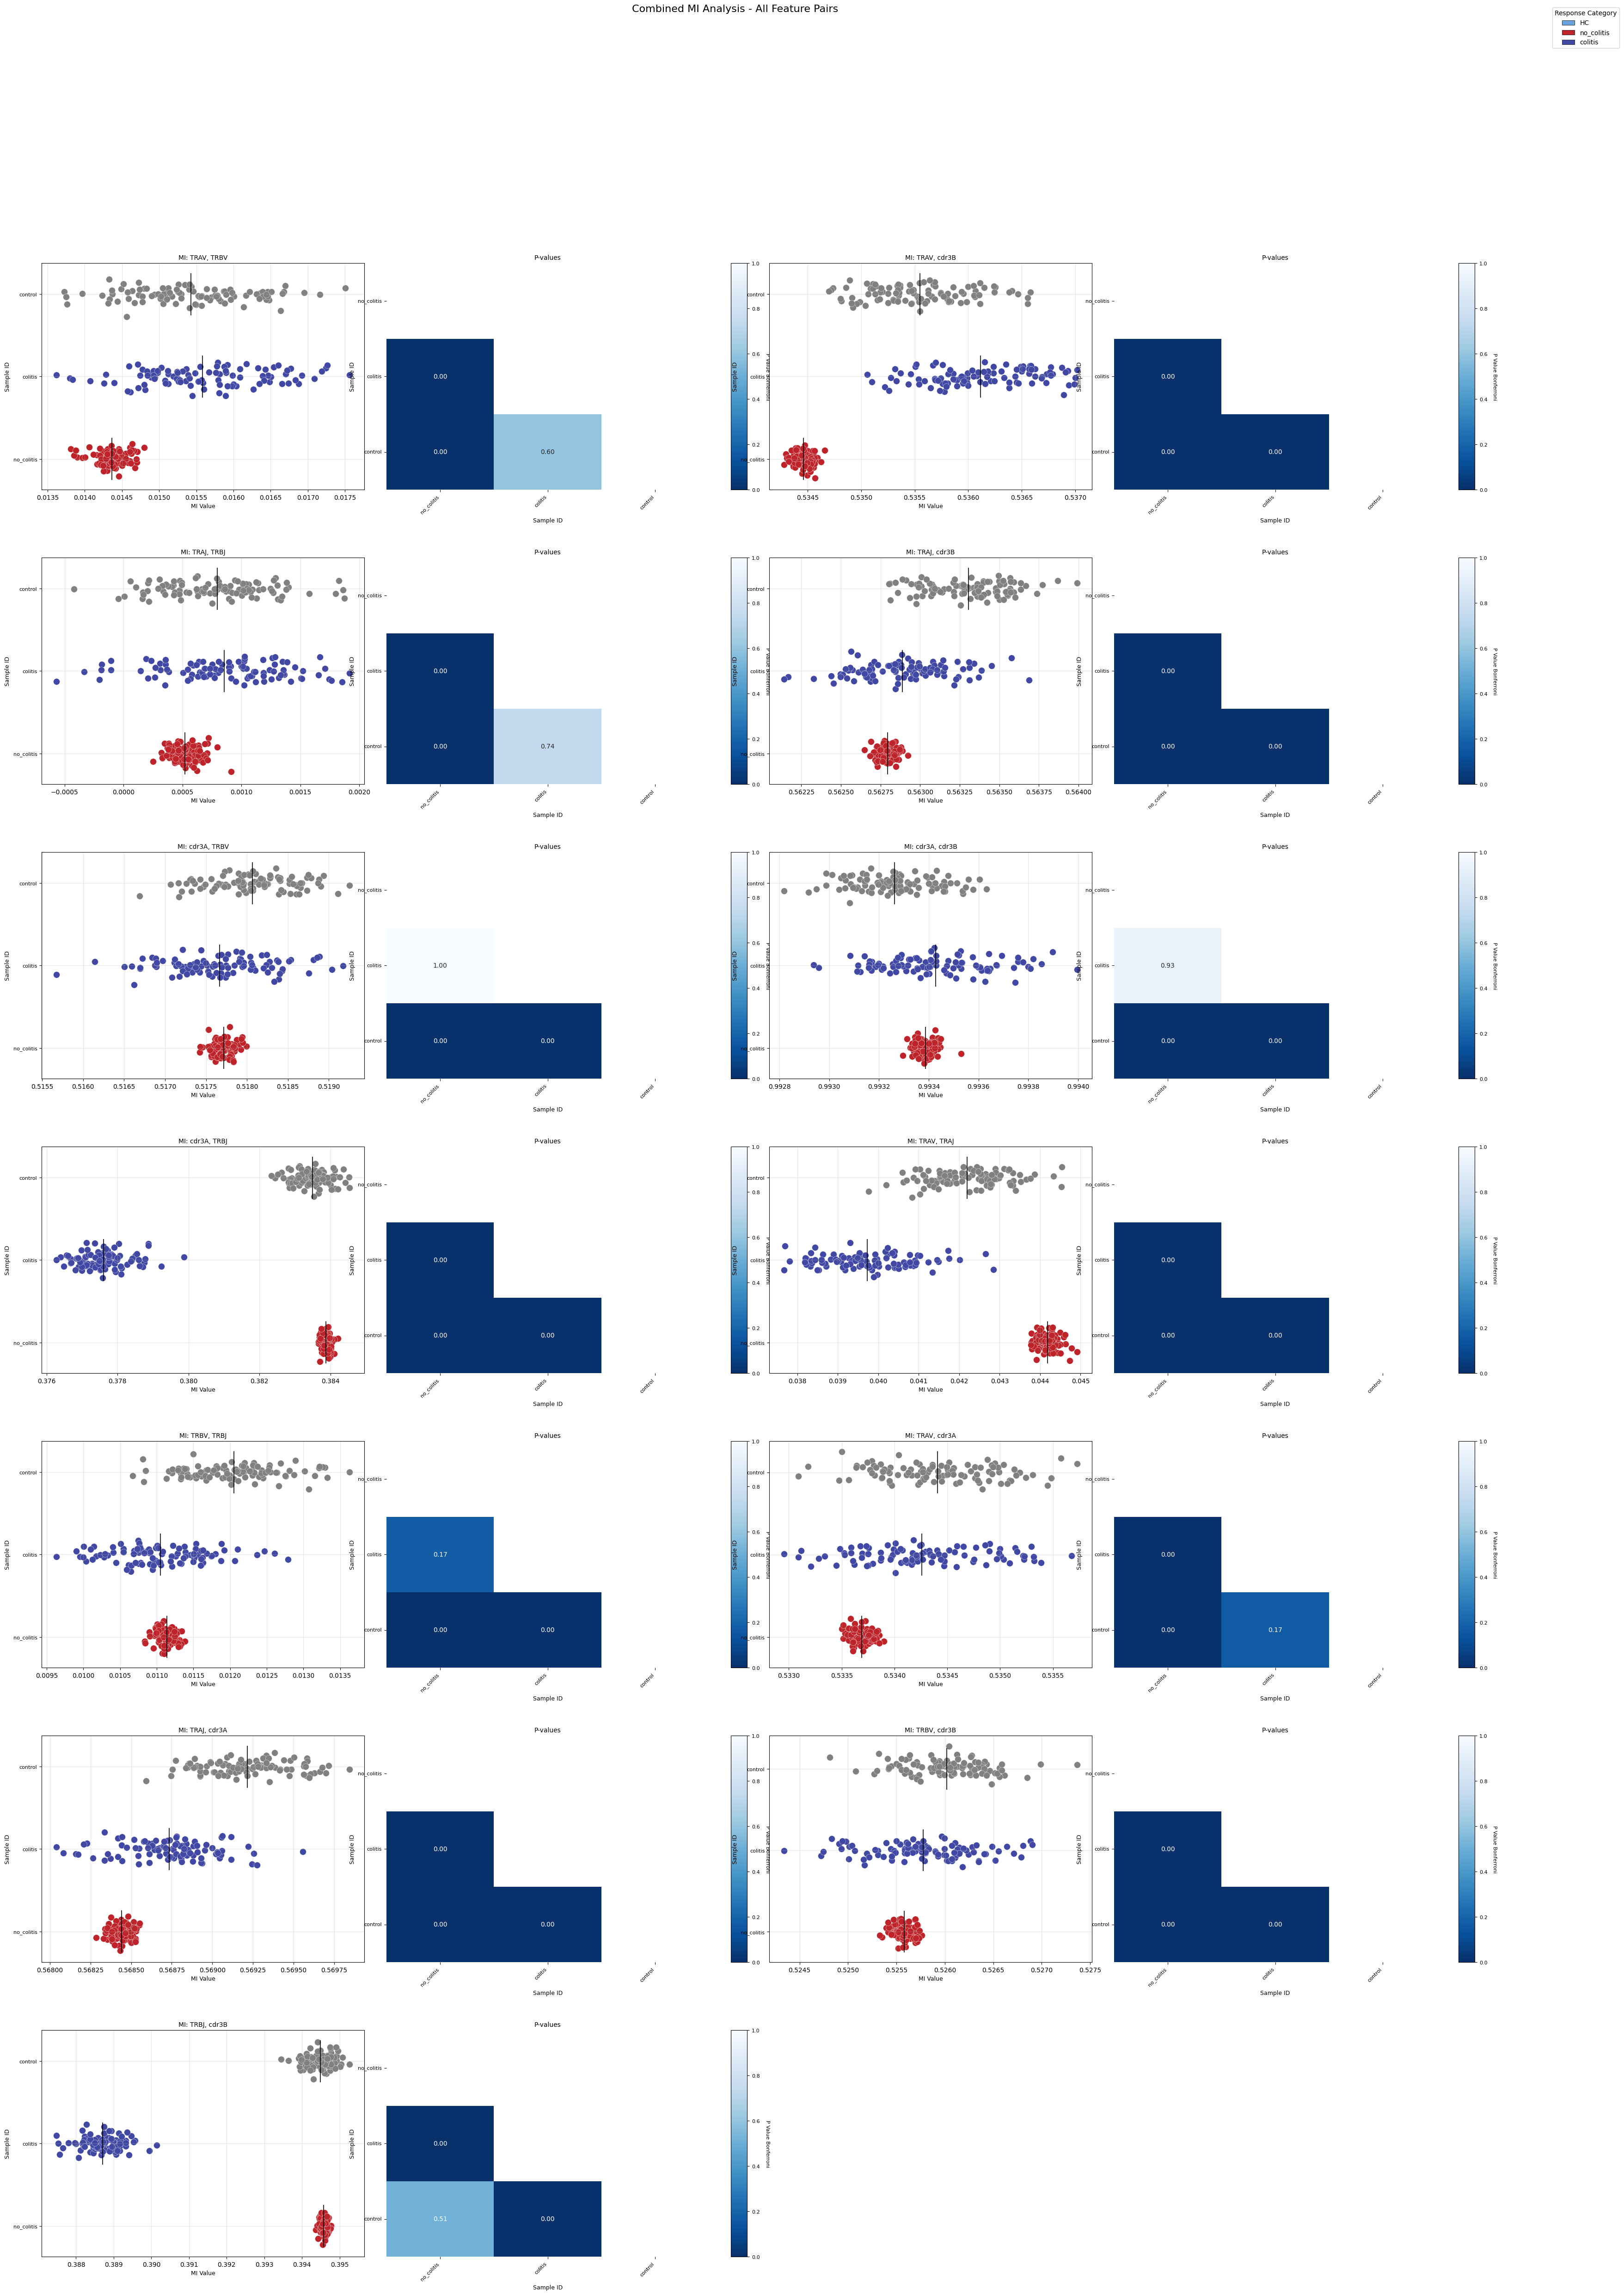

In [ ]:
create_combined_mi_plot("/mnt/d/TCRMI/results/CPI/cohort/mi.pickle", 
                  "/mnt/d/TCRMI/results/CPI/cohort.pickle",
                  save_dir='/mnt/d/TCRMI/figures/CPI/cohort', #'/mnt/d/TCRMI/figures/CPI/cohort'
                  select_features=[('TRAV', 'TRBV'), ('cdr3A', 'cdr3B'),
                                    ('TRAV', 'cdr3B'), ('cdr3A', 'TRBV'),
                                    ('TRAJ', 'TRBJ'), ('cdr3A', 'TRBJ'),
                                    ('TRAJ', 'cdr3B'),])

# Entropy

In [30]:
def create_combined_entropy_plot_with_subfigures(mi_path, samples_path, analysis_type='samples', save_dir=None, 
                            p_value_type='P_Value_Bonferroni', select_features=None,
                            show_individual=False, show_combined=True):
    """
    Create combined plot with scatter-style plots and p-value heatmap for each feature.
    Save individual subfigures and create a combined figure with all subfigures.
    """
    
    # Load data
    mi = pd.read_pickle(mi_path)
    data_dict = pd.read_pickle(samples_path)
    
    # Create save directory if it doesn't exist
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        os.makedirs(os.path.join(save_dir, 'individual_subfigures'), exist_ok=True)
    
    # Store data for all features for combined plot
    all_plot_data = []
    
    # Process each feature
    for feature in list(mi.keys()):
        print(f"Processing {feature}...")
        
        mi_data = mi[feature]
        n_resamples = len(mi_data)
        
        # Configuration for samples analysis
        if analysis_type == 'samples':
            sample_ids = list(data_dict.keys())
            response_order = ["HC", "no_colitis", "colitis"]  # Updated response categories
        
            # Prepare plot data
            plot_data = []
            for sample_idx, sample_id in enumerate(sample_ids):
                for resample_idx in range(n_resamples):
                    if resample_idx in mi_data:
                        mi_values_array = mi_data[resample_idx]
                        if sample_idx < len(mi_values_array):
                            plot_data.append({
                                'Sample_ID': sample_id,
                                'Response_Category': get_response_category(sample_id),
                                'MI_Value': mi_values_array[sample_idx],
                                'Resample_Index': resample_idx
                            })
        
        df_plot = pd.DataFrame(plot_data)
        if df_plot.empty:
            print(f"No data found for {feature}")
            continue
        
        # Calculate mean entropy value for each sample
        sample_means = df_plot.groupby('Sample_ID')['MI_Value'].mean().to_dict()
        
        # Sort samples by response category first, then by mean entropy value within category
        def sort_key_by_mean(sample_id):
            response = get_response_category(sample_id)
            response_priority = response_order.index(response) if response in response_order else 999
            mean_mi = sample_means.get(sample_id, 0)
            return (response_priority, -mean_mi)
        
        unique_samples = sorted(df_plot['Sample_ID'].unique(), key=sort_key_by_mean)
        df_plot_limited = df_plot[df_plot['Sample_ID'].isin(unique_samples)]
        
        # Statistical tests
        results_df, found_significant = perform_statistical_tests(
            df_plot_limited, unique_samples, 
            test_direction='one-sided',
            adjust_pvalues=True,
            adjust_method='Bonferroni'
        )
        
        # Store data for combined plot
        all_plot_data.append({
            'feature': feature,
            'df_plot_limited': df_plot_limited,
            'unique_samples': unique_samples,
            'results_df': results_df
        })
        
        # ============ CREATE AND SAVE INDIVIDUAL SUBFIGURE ============
        fig_individual = plt.figure(figsize=(20, 8))
        gs_individual = fig_individual.add_gridspec(1, 3, width_ratios=[2, 2, 0.1], wspace=0.3)
        
        # LEFT PANEL: SCATTER PLOT WITH MEDIAN LINES
        ax1_individual = fig_individual.add_subplot(gs_individual[0, 0])
        response_colors = {"HC": "#69A3DD", "no_colitis": "#BD2329", 
                          "colitis": "#4048A4"}  # Updated colors
        
        # Prepare data for scatter plot
        y_positions = {sample: i for i, sample in enumerate(unique_samples)}
        
        # Plot individual points with jitter
        np.random.seed(42)  # For reproducible jitter
        for sample_id in unique_samples:
            sample_data = df_plot_limited[df_plot_limited['Sample_ID'] == sample_id]['MI_Value']
            response_cat = get_response_category(sample_id)
            color = response_colors.get(response_cat, 'gray')
            
            # Add vertical jitter
            y_base = y_positions[sample_id]
            y_jitter = np.random.normal(0, 0.1, len(sample_data))  # Small jitter
            y_coords = y_base + y_jitter
            
            # Plot individual points
            ax1_individual.scatter(sample_data, y_coords, 
                                 color=color, alpha=0.6, s=30, 
                                 edgecolors='white', linewidth=0.5)
            
            # Calculate median
            median_val = sample_data.median()
            
            # Plot median as a horizontal line
            line_width = 0.3  # Width of the median line (in y-axis units)
            ax1_individual.plot([median_val, median_val], 
                              [y_base - line_width/2, y_base + line_width/2], 
                              color='black', linewidth=3, alpha=0.8)

        ax1_individual.set_yticks(range(len(unique_samples)))
        ax1_individual.set_yticklabels(unique_samples, rotation=0)
        ax1_individual.xaxis.tick_top()
        ax1_individual.xaxis.set_label_position('top')
        ax1_individual.set_title(f'Entropy Distribution: {feature}', fontsize=14, fontweight='bold')
        ax1_individual.set_ylabel('Sample ID', fontsize=12)
        ax1_individual.set_xlabel('Entropy Value', fontsize=12)
        ax1_individual.grid(True, alpha=0.3, axis='x')
        
        # RIGHT PANEL: HEATMAP (keeping the same as before)
        ax2_individual = fig_individual.add_subplot(gs_individual[0, 1])
        n_samples = len(unique_samples)
        p_matrix = np.ones((n_samples, n_samples))
        sample_to_idx = {sample: i for i, sample in enumerate(unique_samples)}

        for _, row in results_df.iterrows():
            sample1_idx = sample_to_idx[row['Sample1']]
            sample2_idx = sample_to_idx[row['Sample2']]
            p_val = row[p_value_type]
            p_matrix[sample1_idx, sample2_idx] = p_val
            p_matrix[sample2_idx, sample1_idx] = p_val

        mask = np.zeros_like(p_matrix, dtype=bool)
        for i in range(n_samples):
            for j in range(n_samples):
                if j >= i:
                    mask[i, j] = True

        im_individual = sns.heatmap(p_matrix, 
                        mask=mask,
                        annot=True, 
                        fmt='.2f',
                        cmap='Blues_r',
                        vmin=0, 
                        vmax=1,
                        xticklabels=unique_samples,
                        yticklabels=unique_samples,
                        ax=ax2_individual,
                        cbar=False)

        ax2_individual.set_title(f'P-values ({p_value_type.replace("_", " ")})', fontsize=14, fontweight='bold')
        ax2_individual.set_xlabel('Sample ID', fontsize=12)
        ax2_individual.set_ylabel('Sample ID', fontsize=12)
        ax2_individual.set_xticklabels(unique_samples, rotation=45, ha='right')
        ax2_individual.set_yticklabels(unique_samples, rotation=0)
        
        # COLORBAR
        ax3_individual = fig_individual.add_subplot(gs_individual[0, 2])
        cbar_individual = plt.colorbar(im_individual.collections[0], cax=ax3_individual)
        cbar_individual.set_label(f'{p_value_type.replace("_", " ")}', rotation=270, labelpad=20)
        
        # LEGEND - Updated for scatter plot style with median line
        legend_elements = []
        sample_responses = [get_response_category(sample) for sample in unique_samples]
        unique_responses = list(set(sample_responses))
        
        for response in ["HC", "no_colitis", "colitis"]:
            if response in unique_responses:
                legend_elements.append(
                    plt.Line2D([0], [0], marker='o', color='w', 
                              markerfacecolor=response_colors[response], 
                              markersize=10, label=response, 
                              markeredgecolor='black', markeredgewidth=0.5)
                )
        
        # Add median line to legend
        legend_elements.append(
            plt.Line2D([0], [0], color='black', linewidth=3, 
                      label='Median', alpha=0.8)
        )
        
        fig_individual.legend(handles=legend_elements, title='Response Category', 
                  bbox_to_anchor=(0.95, 0.85), loc='upper left', fontsize=10)
        
        plt.suptitle(f'Entropy Analysis: {feature}', fontsize=16, y=0.95)
        
        # Save individual subfigure
        if save_dir:
            if select_features is None or feature in select_features:
                individual_save_path = os.path.join(save_dir, 'individual_subfigures', 
                                                  f'entropy_subfigure_{feature}.pdf')
                fig_individual.savefig(individual_save_path, transparent=True, bbox_inches='tight', dpi=300)
                print(f"Individual entropy subfigure saved to: {individual_save_path}")
        
        # Show individual plot if requested
        if show_individual:
            plt.show()
        else:
            plt.close(fig_individual)  # Close to prevent display in notebook
    
    # ============ CREATE COMBINED FIGURE WITH ALL SUBFIGURES ============
    if not all_plot_data:
        print("No data to create combined figure")
        return
    
    n_features = len(all_plot_data)
    n_cols = min(2, n_features)  # 最多2列
    n_rows = (n_features + n_cols - 1) // n_cols
    
    # Create combined figure
    fig_combined = plt.figure(figsize=(20*n_cols, 8*n_rows))
    
    for idx, data in enumerate(all_plot_data):
        feature = data['feature']
        df_plot_limited = data['df_plot_limited']
        unique_samples = data['unique_samples']
        results_df = data['results_df']
        
        # Calculate subplot position
        row = idx // n_cols
        col = idx % n_cols
        
        # Create gridspec for this subplot
        gs_sub = fig_combined.add_gridspec(n_rows, n_cols*3, 
                                          width_ratios=[2, 2, 0.1]*n_cols, 
                                          wspace=0.1, hspace=0.3)
        
        # LEFT PANEL: SCATTER PLOT WITH MEDIAN LINES
        ax1 = fig_combined.add_subplot(gs_sub[row, col*3])
        
        response_colors = {"HC": "#69A3DD", "no_colitis": "#BD2329", 
                          "colitis": "#4048A4"}
        
        # Prepare data for scatter plot
        y_positions = {sample: i for i, sample in enumerate(unique_samples)}
        
        # Plot individual points with jitter
        np.random.seed(42)  # For reproducible jitter
        for sample_id in unique_samples:
            sample_data = df_plot_limited[df_plot_limited['Sample_ID'] == sample_id]['MI_Value']
            response_cat = get_response_category(sample_id)
            color = response_colors.get(response_cat, 'gray')
            
            # Add vertical jitter
            y_base = y_positions[sample_id]
            y_jitter = np.random.normal(0, 0.05, len(sample_data))  # Smaller jitter for combined plot
            y_coords = y_base + y_jitter
            
            # Plot individual points (smaller for combined plot)
            ax1.scatter(sample_data, y_coords, 
                       color=color, alpha=0.5, s=80, 
                       edgecolors='white', linewidth=0.3)
            
            # Calculate median
            median_val = sample_data.median()
            
            # Plot median as a horizontal line (smaller for combined plot)
            line_width = 0.2  # Smaller width for combined plot
            ax1.plot([median_val, median_val], 
                    [y_base - line_width/2, y_base + line_width/2], 
                    color='black', linewidth=2, alpha=0.8)

        ax1.set_yticks(range(len(unique_samples)))
        ax1.set_yticklabels(unique_samples, rotation=0, fontsize=8)
        ax1.xaxis.tick_top()
        ax1.xaxis.set_label_position('top')
        ax1.set_title(f'Entropy: {feature}', fontsize=10)
        ax1.set_ylabel('Sample ID', fontsize=9)
        ax1.set_xlabel('Entropy Value', fontsize=9)
        ax1.grid(True, alpha=0.3, axis='x')
        
        # RIGHT PANEL: HEATMAP (same as before)
        ax2 = fig_combined.add_subplot(gs_sub[row, col*3+1])
        
        n_samples = len(unique_samples)
        p_matrix = np.ones((n_samples, n_samples))
        sample_to_idx = {sample: i for i, sample in enumerate(unique_samples)}

        for _, row_data in results_df.iterrows():
            sample1_idx = sample_to_idx[row_data['Sample1']]
            sample2_idx = sample_to_idx[row_data['Sample2']]
            p_val = row_data[p_value_type]
            p_matrix[sample1_idx, sample2_idx] = p_val
            p_matrix[sample2_idx, sample1_idx] = p_val

        mask = np.zeros_like(p_matrix, dtype=bool)
        for i in range(n_samples):
            for j in range(n_samples):
                if j >= i:
                    mask[i, j] = True

        im = sns.heatmap(p_matrix, 
                        mask=mask,
                        annot=True, 
                        fmt='.2f',
                        cmap='Blues_r',
                        vmin=0, 
                        vmax=1, linewidths=0.5,
                        xticklabels=unique_samples,
                        yticklabels=unique_samples,
                        ax=ax2, 
                        cbar=False)

        ax2.set_title(f'P-values', fontsize=10)
        ax2.set_xlabel('Sample ID', fontsize=9)
        ax2.set_ylabel('Sample ID', fontsize=9)
        ax2.set_xticklabels(unique_samples, rotation=45, ha='right', fontsize=8)
        ax2.set_yticklabels(unique_samples, rotation=0, fontsize=8)
        
        # COLORBAR
        ax3 = fig_combined.add_subplot(gs_sub[row, col*3+2])
        cbar = plt.colorbar(im.collections[0], cax=ax3)
        cbar.set_label(f'{p_value_type.replace("_", " ")}', rotation=270, labelpad=15, fontsize=8)
        cbar.ax.tick_params(labelsize=8)
    
    # Add overall legend - Updated for scatter plot style with median line
    legend_elements = []
    response_colors = {"HC": "#69A3DD", "no_colitis": "#BD2329", 
                      "colitis": "#4048A4"}
    
    for response in ["HC", "no_colitis", "colitis"]:
        legend_elements.append(
            plt.Line2D([0], [0], marker='o', color='w', 
                      markerfacecolor=response_colors[response], 
                      markersize=10, label=response, 
                      markeredgecolor='black', markeredgewidth=0.5)
        )
    
    # Add median line to legend
    legend_elements.append(
        plt.Line2D([0], [0], color='black', linewidth=3, 
                  label='Median', alpha=0.8)
    )
    
    fig_combined.legend(handles=legend_elements, title='Response Category', 
              bbox_to_anchor=(0.98, 0.98), loc='upper right', fontsize=10)
    
    plt.suptitle('Combined Entropy Analysis - All Features', fontsize=16, y=0.98)
    
    # Save combined figure
    if save_dir:
        combined_save_path = os.path.join(save_dir, 'combined_all_entropy_analyses.pdf')
        fig_combined.savefig(combined_save_path, transparent=True, bbox_inches='tight', dpi=300)
        print(f"Combined entropy figure saved to: {combined_save_path}")
    
    # Show combined plot if requested
    if show_combined:
        plt.show()
    else:
        plt.close(fig_combined)


Processing cdr3A...
Individual entropy subfigure saved to: /mnt/d/TCRMI/figures/CPI/cohort/individual_subfigures/entropy_subfigure_cdr3A.pdf
Processing cdr3B...
Individual entropy subfigure saved to: /mnt/d/TCRMI/figures/CPI/cohort/individual_subfigures/entropy_subfigure_cdr3B.pdf
Processing TRAV...
Individual entropy subfigure saved to: /mnt/d/TCRMI/figures/CPI/cohort/individual_subfigures/entropy_subfigure_TRAV.pdf
Processing TRBV...
Individual entropy subfigure saved to: /mnt/d/TCRMI/figures/CPI/cohort/individual_subfigures/entropy_subfigure_TRBV.pdf
Processing TRAJ...
Processing TRBJ...
Processing cdr3A|cdr3B...
Individual entropy subfigure saved to: /mnt/d/TCRMI/figures/CPI/cohort/individual_subfigures/entropy_subfigure_cdr3A|cdr3B.pdf
Processing cdr3B|cdr3A...
Individual entropy subfigure saved to: /mnt/d/TCRMI/figures/CPI/cohort/individual_subfigures/entropy_subfigure_cdr3B|cdr3A.pdf
Processing TRAV|TRBV...
Individual entropy subfigure saved to: /mnt/d/TCRMI/figures/CPI/cohort/i

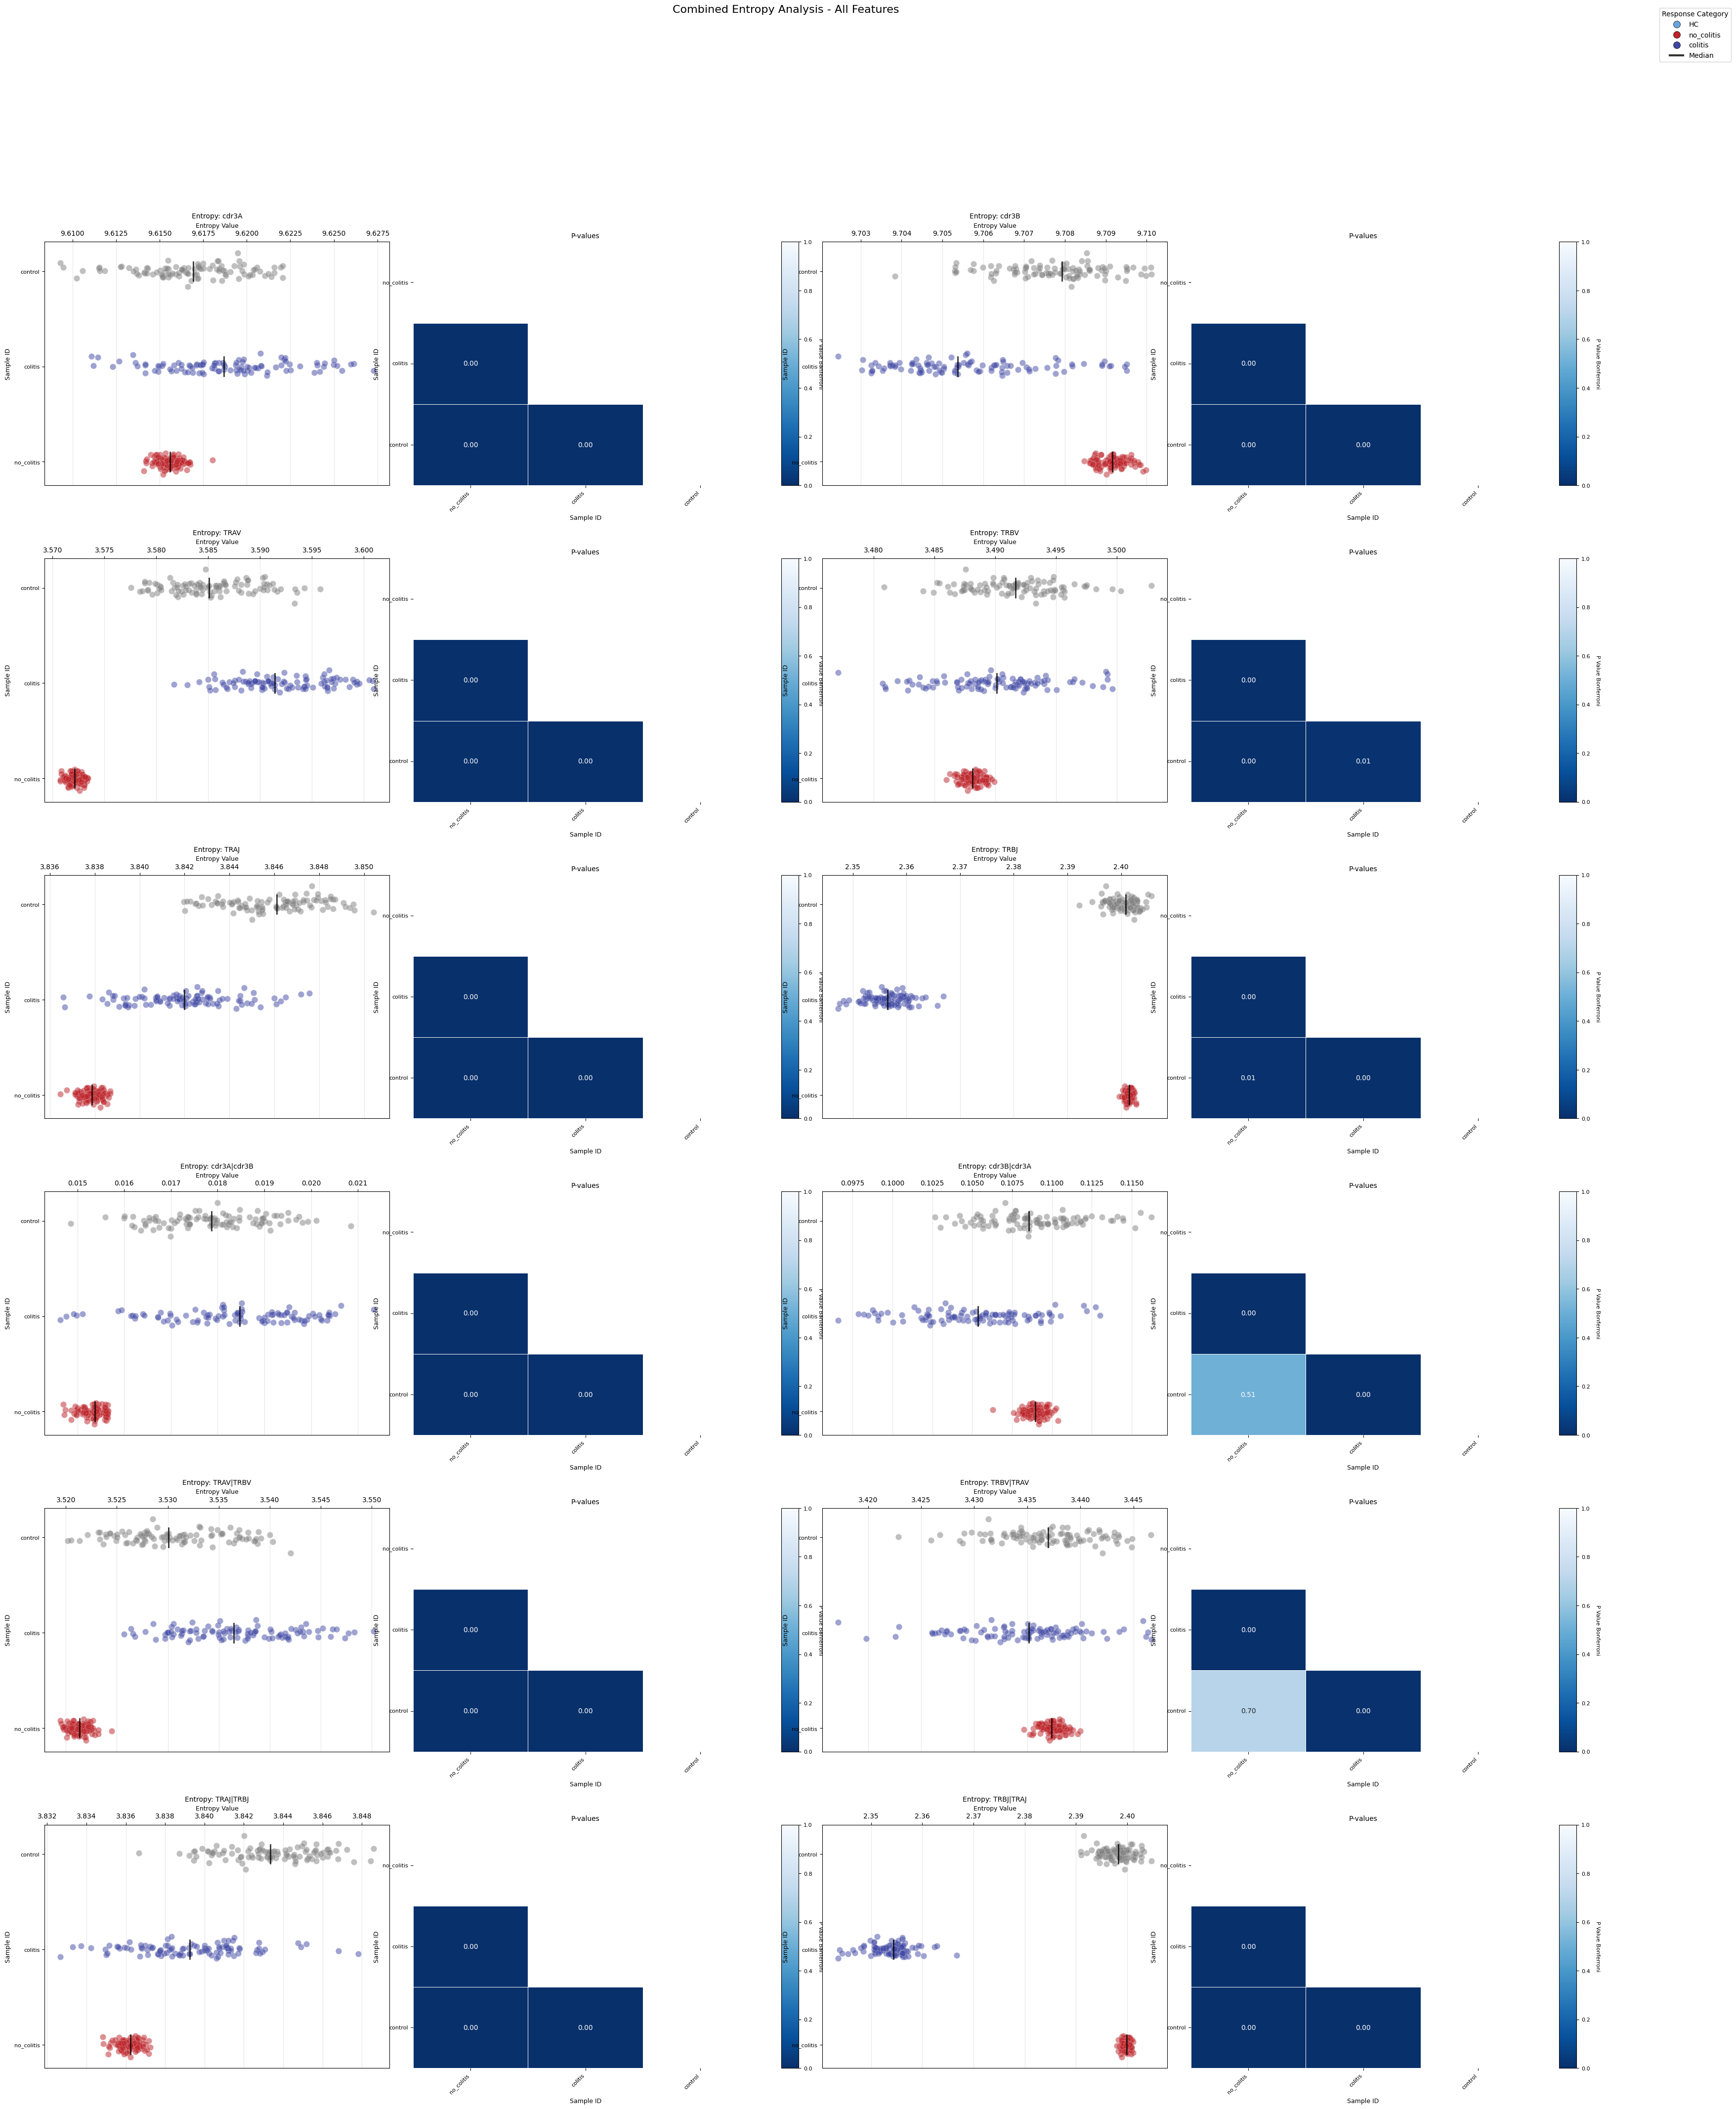

In [11]:
create_combined_entropy_plot_with_subfigures("/mnt/d/TCRMI/results/CPI/cohort/entropy.pickle", 
                  "/mnt/d/TCRMI/results/CPI/cohort.pickle",
                  save_dir="/mnt/d/TCRMI/figures/CPI/cohort",
                  select_features=['cdr3A','cdr3B','TRAV','TRBV',
                                   'cdr3A|cdr3B','cdr3B|cdr3A',
                                   'TRAV|TRBV','TRBV|TRAV'])